In [1]:
import numpy as np

rng = np.random.default_rng(seed=42)
m = 200

X = 2*rng.random((m,1))
y = 4+3*X+rng.standard_normal((m,1))

In [2]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X)
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

In [3]:
theta_best

array([[3.69084138],
       [3.32960458]])

In [4]:
X_new = np.array([[0],[2]])
X_new_b = add_dummy_feature(X_new)
y_predict = X_new_b @ theta_best
y_predict

array([[ 3.69084138],
       [10.35005055]])

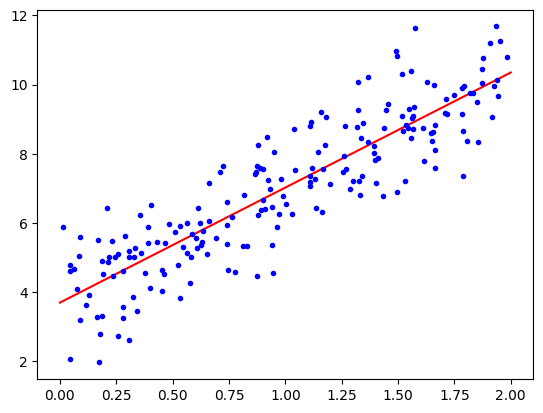

In [5]:
import matplotlib.pyplot as plt

plt.plot(X_new,y_predict,"r-",label="Predictions")
plt.plot(X,y,"b.")
plt.show()

In [6]:
#Scikit Learn Linear Regression
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()

lin_reg.fit(X,y)
lin_reg.intercept_,lin_reg.coef_

(array([3.69084138]), array([[3.32960458]]))

In [7]:
lin_reg.predict(X_new)

array([[ 3.69084138],
       [10.35005055]])

In [8]:
theta_best_svd,residuals,rank ,s = np.linalg.lstsq(X_b,y,rcond=1e-6)
theta_best_svd

array([[3.69084138],
       [3.32960458]])

In [9]:
np.linalg.pinv(X_b) @ y

array([[3.69084138],
       [3.32960458]])

In [10]:
#Batch Gradient Descent

eta = 0.1
n_epochs = 1000
m = len(X_b)

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2,1))

for epochs in range(n_epochs):
    gradients = 2 / m * X_b.T @ (X_b @ theta - y)
    theta = theta - eta*gradients

In [11]:
theta

array([[3.69084138],
       [3.32960458]])

In [12]:
import numpy as np

n_epochs = 50
t0, t1 = 5, 50  

def learning_schedule(t):
    return t0 / (t + t1)

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2, 1))

m = len(X_b) 

for epoch in range(n_epochs):
    for iteration in range(m):
        random_index = rng.integers(m)
        xi = X_b[random_index : random_index + 1]
        yi = y[random_index : random_index + 1]

        gradients = 2 * xi.T @ (xi @ theta - yi)

        eta = learning_schedule(epoch * m + iteration)
        
        theta = theta - eta * gradients

In [13]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(
    max_iter=1000, 
    tol=1e-5, 
    penalty=None, 
    eta0=0.01,
    n_iter_no_change=100, 
    random_state=42
)

sgd_reg.fit(X, y.ravel())

,loss,'squared_error'
,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,1e-05
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,42


In [14]:
sgd_reg.intercept_,sgd_reg.coef_

(array([3.68899733]), array([3.33054574]))

In [15]:
n_epochs = 100
minibatch_size = 32 
m = len(X_b)

for epoch in range(n_epochs):
   
    shuffled_indices = np.random.permutation(m)
    X_b_shuffled = X_b[shuffled_indices]
    y_shuffled = y[shuffled_indices]
    
    
    for i in range(0, m, minibatch_size):
        xi = X_b_shuffled[i : i + minibatch_size]
        yi = y_shuffled[i : i + minibatch_size]
        
        gradients = 2 / len(xi) * xi.T @ (xi @ theta - yi)
        
        theta = theta - eta * gradients